# Logistic Regression (scikit-learn)

This notebook trains a binary **Logistic Regression** model using **scikit-learn** (instead of the manual gradient ascent implementation).

**Aim:** learn to load the dataset, preprocess it, fit `LogisticRegression`, and evaluate predictions.

## Imports (aim of this cell)

Bring in the libraries we need:

- `numpy` for array operations
- `utils.load_classification_data` to load the same dataset format as the gradient-ascent notebook
- `train_test_split` to create a hold-out test set
- `LogisticRegression` as the scikit-learn classifier
- metrics (`accuracy_score`, `confusion_matrix`, `roc_auc_score`) to evaluate performance
- `matplotlib` only if we later want plots

In [7]:
import numpy as np

from utils import load_classification_data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt

## Load the dataset (aim of this cell)

`load_classification_data()` returns:

- `X_raw` with shape `(n_features, n_samples)`
- `y_raw` with shape `(1, n_samples)`

scikit-learn expects different shapes, so we will reshape later.

In [8]:
X_raw, y_raw = load_classification_data()

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

X_raw shape: (30, 569)
y_raw shape: (1, 569)


## Preprocess + split (aim of this cell)

We do four things here:

1. Convert shapes for scikit-learn:
   - `X = X_raw.T` so it becomes `(n_samples, n_features)`
   - `y = y_raw.ravel()` so it becomes `(n_samples,)`
2. Split into train/test with stratification to keep the same class ratio.
3. Apply z-score normalization using training statistics only (prevents data leakage).
4. Output `X_train, X_test, y_train, y_test` in sklearn-ready shapes.

### Why we standardize features (z-score)?

The code below does **z-score standardization**:

- `X_mean = X_train.mean(...)` computes the mean of each feature **using only the training set**.
- `X_std = X_train.std(...)` computes the standard deviation of each feature **using only the training set**.
- `X_train = (X_train - X_mean) / X_std_safe` rescales each feature so it has approximately **mean 0** and **std 1**.
- The same transformation is applied to `X_test` using the **training** `X_mean`/`X_std`.

**Aim (why do this?):** Logistic Regression in scikit-learn uses gradient-based optimization and regularization, and it is sensitive to feature scale. If one feature has much larger magnitude than another, it can dominate the optimization and slow convergence.

**Why “training-only” stats?** Using train statistics avoids **data leakage**. The test set must remain unseen until evaluation.

**Why `X_std_safe`?** If a feature has zero variance in the training set (`X_std == 0`), dividing by zero would crash or create NaNs. `X_std_safe = 1.0` for those cases prevents that.

In [9]:
# Convert to sklearn-friendly shapes
X = X_raw.T  # (n_samples, n_features)
y = y_raw.ravel()  # (n_samples,)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

# Z-score normalization using TRAIN statistics only
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True)
X_std_safe = np.where(X_std == 0, 1.0, X_std)

X_train = (X_train - X_mean) / X_std_safe
X_test = (X_test - X_mean) / X_std_safe

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (455, 30) y_train: (455,)
X_test: (114, 30) y_test: (114,)


## !!!Cursor Explain!!! — Why we don’t manually add an intercept row

Your gradient-ascent notebook manually appended a row of ones to represent the intercept explicitly.

In scikit-learn, `LogisticRegression` already includes an intercept by default (`fit_intercept=True`).
So we should provide only the real features (no manually added bias column/row), otherwise we would effectively double-count the intercept.

## Train LogisticRegression (aim of this cell)

**Goal:** create the classifier and fit it with
```python
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)
```

We also set `max_iter` to ensure the solver converges.

In [10]:
classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(X_train, y_train)

print("Training complete.")

Training complete.


## Evaluate on the test set (aim of this cell)

We evaluate how well the trained classifier generalizes:

- `accuracy_score`: percentage of correct predictions
- `confusion_matrix`: breakdown of TP/TN/FP/FN
- `roc_auc_score`: quality of predicted probabilities for class 1

In [11]:
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("Confusion matrix:\n", cm)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9824561403508771
Confusion matrix:
 [[40  2]
 [ 0 72]]
ROC-AUC: 0.9957010582010581


## Inspect learned coefficients (aim of this cell)

Logistic Regression learns a weight for each feature. Features with larger absolute coefficient values typically have stronger influence on the decision boundary.

We print the intercept and the top 10 coefficients.

In [12]:
from sklearn.datasets import load_breast_cancer

breast = load_breast_cancer()
feature_names = breast.feature_names

coefs = classifier.coef_[0]
top_idx = np.argsort(np.abs(coefs))[::-1][:10]

print("Intercept:", classifier.intercept_[0])
print("Top 10 coefficients by absolute value:")
for i in top_idx:
    print(f"  {feature_names[i]}: coef={coefs[i]:+.4f}")

Intercept: 0.3411727215967604
Top 10 coefficients by absolute value:
  radius error: coef=-1.3247
  worst radius: coef=-0.9845
  worst texture: coef=-0.9734
  mean concave points: coef=-0.9631
  worst area: coef=-0.8675
  worst concave points: coef=-0.8619
  area error: coef=-0.8401
  worst perimeter: coef=-0.7983
  worst symmetry: coef=-0.7812
  worst concavity: coef=-0.7638


## Decision boundary (2D visualization)

**Aim:** Logistic regression is trained on many features, so a full decision surface is high-dimensional. To visualize it, we:

- Pick the **top 2 features** with the largest absolute coefficients (`|coef|`).
- Create a 2D grid for those two features.
- Keep all **other features fixed** at their **training mean**.
- Plot the region where the model predicts class 0 vs class 1.

The **black line** is the boundary where `P(class=1) = 0.5`.

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_44952\2752232788.py:44: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


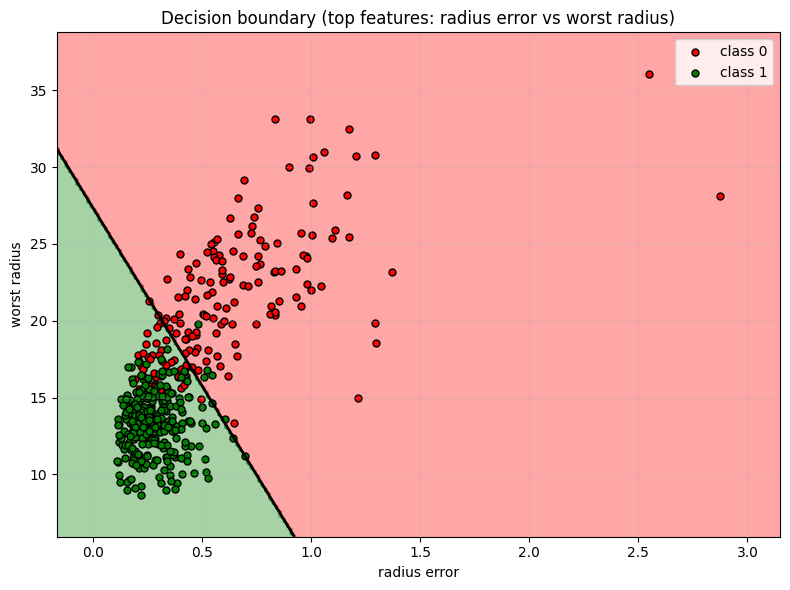

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Reconstruct RAW feature values for nicer axes
X_train_raw = X_train * X_std_safe + X_mean
X_test_raw = X_test * X_std_safe + X_mean


i1, i2 = int(top_idx[0]), int(top_idx[1])

x1 = X_train_raw[:, i1]
x2 = X_train_raw[:, i2]

pad1 = 0.1 * (x1.max() - x1.min()) if x1.max() > x1.min() else 1.0
pad2 = 0.1 * (x2.max() - x2.min()) if x2.max() > x2.min() else 1.0

x1_grid = np.linspace(x1.min() - pad1, x1.max() + pad1, 200)
x2_grid = np.linspace(x2.min() - pad2, x2.max() + pad2, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)


base = np.tile(X_mean, (X1.size, 1))  # (grid_points, n_features)
base[:, i1] = X1.ravel()
base[:, i2] = X2.ravel()

# Standardize using TRAIN statistics
X_grid_std = (base - X_mean) / X_std_safe

# Probability of class 1 for each grid point
Z_prob = classifier.predict_proba(X_grid_std)[:, 1].reshape(X1.shape)
Z_class = (Z_prob >= 0.5).astype(int)

cmap_bg = ListedColormap(('red', 'green'))

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z_class, alpha=0.35, cmap=cmap_bg)
plt.contour(X1, X2, Z_prob, levels=[0.5], colors='black', linewidths=2)

# Scatter training points
for cls in np.unique(y_train):
    cls = int(cls)
    mask = (y_train == cls)
    plt.scatter(
        X_train_raw[mask, i1],
        X_train_raw[mask, i2],
        c=cmap_bg(cls),
        edgecolor='k',
        s=25,
        label=f'class {cls}'
    )

plt.title(f'Decision boundary (top features: {feature_names[i1]} vs {feature_names[i2]})')
plt.xlabel(feature_names[i1])
plt.ylabel(feature_names[i2])
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Single prediction example (aim of this cell)

We take one test sample and compute:

- `prob_one`: predicted probability for class 1
- `pred_one`: predicted class label (0 or 1)

In [13]:
x_one = X_test[0:1]
true_one = y_test[0]

prob_one = classifier.predict_proba(x_one)[0, 1]
pred_one = classifier.predict(x_one)[0]

print(f"Predicted probability (class 1): {prob_one:.4f}")
print(f"Predicted class: {pred_one}")
print(f"True label: {true_one}")

Predicted probability (class 1): 0.0108
Predicted class: 0
True label: 0
